In [1]:
import uproot
import pandas as pd
import numpy as np
import glob


In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [89]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','skimhad']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [90]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [91]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,466903.000000,466903.000000,466903.000000,466903.000000,466903.000000,466903.000000
mean,1.787387,0.194923,0.427572,1.637710,-0.003142,0.877019
std,0.152759,0.497347,0.491706,0.936025,0.999996,0.328415
min,1.500002,-0.999633,-0.892108,0.400001,-1.000000,0.000000
25%,1.662441,-0.194909,0.097568,0.833757,-1.000000,1.000000
50%,1.775429,0.258803,0.597567,1.483630,-1.000000,1.000000
75%,1.933502,0.618096,0.845029,2.265353,1.000000,1.000000
max,2.099994,1.000000,0.976842,5.600719,1.000000,1.000000


In [92]:
df_proc13 = df_proc13.query('Dp_M> 1.7 & Dp_M<2.1')


In [93]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,310608.000000,310608.000000,310608.000000,310608.000000,310608.000000,310608.000000
mean,1.874211,0.182845,0.422953,1.673688,-0.004076,0.871442
std,0.104611,0.502083,0.495654,0.959600,0.999993,0.334710
min,1.700001,-0.999633,-0.886036,0.400008,-1.000000,0.000000
25%,1.775999,-0.214174,0.085717,0.847035,-1.000000,1.000000
50%,1.872590,0.239065,0.594707,1.525319,-1.000000,1.000000
75%,1.964274,0.611368,0.845874,2.317480,1.000000,1.000000
max,2.099994,1.000000,0.974742,5.600719,1.000000,1.000000


In [94]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
skimhad            False
dtype: bool


In [95]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz_skimhad"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','skimhad']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [96]:
df_proc13_skimhad = pd.concat(dataframes, ignore_index=True)


In [97]:
df_proc13_skimhad.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,386645.000000,386645.000000,386645.000000,386645.000000,386645.000000,386645.0
mean,1.785268,0.198677,0.439812,1.540058,-0.005201,1.0
std,0.152706,0.472123,0.470567,0.867538,0.999988,0.0
min,1.500002,-0.999633,-0.892108,0.400001,-1.000000,1.0
25%,1.660326,-0.174508,0.122825,0.796843,-1.000000,1.0
50%,1.773249,0.251949,0.595831,1.386679,-1.000000,1.0
75%,1.931801,0.599042,0.838875,2.127947,1.000000,1.0
max,2.099993,0.999976,0.976842,5.339994,1.000000,1.0


In [98]:
df_proc13_skimhad = df_proc13_skimhad.query('Dp_M> 1.7 & Dp_M<2.1')


In [99]:
df_proc13_skimhad.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,255502.000000,255502.000000,255502.000000,255502.000000,255502.000000,255502.0
mean,1.873354,0.183809,0.433832,1.573141,-0.005057,1.0
std,0.103666,0.476197,0.474544,0.892183,0.999989,0.0
min,1.700003,-0.999633,-0.886036,0.400008,-1.000000,1.0
25%,1.775568,-0.195850,0.109086,0.806997,-1.000000,1.0
50%,1.872319,0.229366,0.590945,1.423000,-1.000000,1.0
75%,1.963831,0.588113,0.838319,2.175422,1.000000,1.0
max,2.099993,0.999976,0.974742,5.339994,1.000000,1.0


In [100]:
nan_columns = df_proc13_skimhad.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
skimhad            False
dtype: bool


In [101]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


In [102]:
tree_to_compare = "etapip_gg"
plt.rcParams['font.family'] = 'DejaVu Sans'


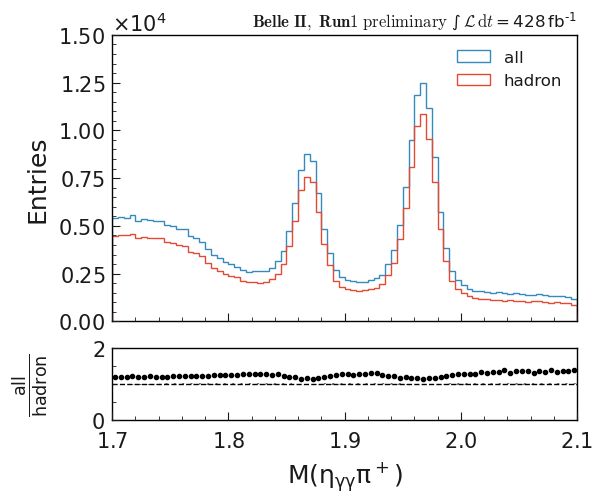

In [105]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_proc13_skimhad[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="all",
    h2_label="hadron",
    comparison="split_ratio",
)

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_all_hlt_compare_{tree_to_compare}_{name}.png", bbox_inches="tight")

In [28]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','skimhad']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [29]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [30]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,253651.000000,253651.000000,253651.000000,253651.000000,253651.000000,253651.000000
mean,1.766053,0.234135,0.460565,1.609131,-0.008764,0.993503
std,0.154947,0.468445,0.463590,0.876812,0.999964,0.080343
min,1.500001,-0.992832,-0.903704,0.400005,-1.000000,0.000000
25%,1.636979,-0.128217,0.157260,0.863993,-1.000000,1.000000
50%,1.749231,0.303110,0.617545,1.485538,-1.000000,1.000000
75%,1.887009,0.627774,0.852339,2.205388,1.000000,1.000000
max,2.099998,0.999989,0.977868,6.247939,1.000000,1.000000


In [31]:
df_proc13 = df_proc13.query('Dp_M> 1.7 & Dp_M<2.1')


In [32]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,155161.000000,155161.000000,155161.000000,155161.000000,155161.000000,155161.000000
mean,1.867150,0.214466,0.450313,1.629382,-0.010821,0.993542
std,0.104156,0.475770,0.472268,0.903463,0.999945,0.080101
min,1.700002,-0.992832,-0.903704,0.400005,-1.000000,0.000000
25%,1.768358,-0.160411,0.130610,0.860294,-1.000000,1.000000
50%,1.868232,0.272006,0.611436,1.503238,-1.000000,1.000000
75%,1.964905,0.615841,0.852998,2.237833,1.000000,1.000000
max,2.099998,0.999989,0.977868,6.247939,1.000000,1.000000


In [33]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
skimhad            False
dtype: bool


In [34]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz_skimhad"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','skimhad']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [35]:
df_proc13_skimhad = pd.concat(dataframes, ignore_index=True)


In [36]:
df_proc13_skimhad.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,237539.000000,237539.000000,237539.000000,237539.000000,237539.000000,237539.0
mean,1.766001,0.233375,0.459828,1.602111,-0.008213,1.0
std,0.154919,0.467499,0.463397,0.871547,0.999968,0.0
min,1.500001,-0.992832,-0.903704,0.400005,-1.000000,1.0
25%,1.636947,-0.128022,0.156781,0.861431,-1.000000,1.0
50%,1.749285,0.302597,0.616541,1.478574,-1.000000,1.0
75%,1.886611,0.626265,0.851335,2.195151,1.000000,1.0
max,2.099998,0.999989,0.977868,6.247939,1.000000,1.0


In [37]:
df_proc13_skimhad = df_proc13_skimhad.query('Dp_M> 1.7 & Dp_M<2.1')


In [38]:
df_proc13_skimhad.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,145309.000000,145309.000000,145309.000000,145309.000000,145309.000000,145309.0
mean,1.867094,0.213242,0.449162,1.622033,-0.010123,1.0
std,0.104089,0.474719,0.472051,0.897728,0.999952,0.0
min,1.700002,-0.992832,-0.903704,0.400005,-1.000000,1.0
25%,1.768380,-0.160723,0.129052,0.857498,-1.000000,1.0
50%,1.868186,0.271114,0.609582,1.496266,-1.000000,1.0
75%,1.964853,0.613967,0.851456,2.227268,1.000000,1.0
max,2.099998,0.999989,0.977868,6.247939,1.000000,1.0


In [39]:
nan_columns = df_proc13_skimhad.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
skimhad            False
dtype: bool


In [40]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


In [41]:
tree_to_compare = "etapip_pipipi"
plt.rcParams['font.family'] = 'DejaVu Sans'


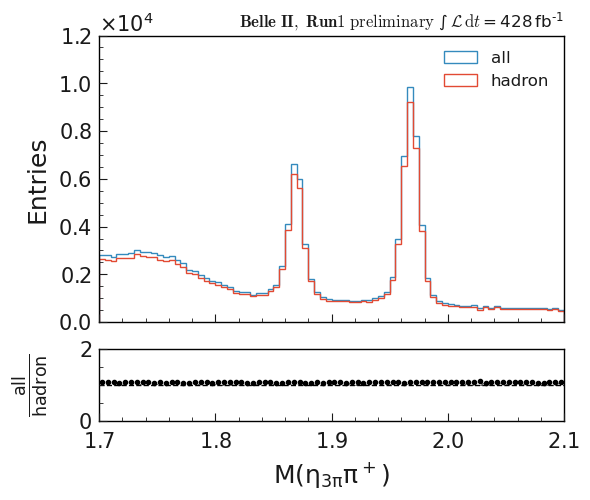

In [43]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_proc13_skimhad[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="all",
    h2_label="hadron",
    comparison="split_ratio",
)

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_all_hlt_compare_{tree_to_compare}_{name}.png", bbox_inches="tight")

In [44]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','skimhad']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [45]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [46]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,11763.000000,11763.000000,11763.000000,11763.000000,11763.000000,11763.000000
mean,1.677429,0.272480,0.500938,1.603652,0.008586,0.964550
std,0.149251,0.469664,0.442754,0.773960,1.000006,0.184923
min,1.500070,-0.914492,-0.884835,0.405252,-1.000000,0.000000
25%,1.579929,-0.103039,0.212768,0.972684,-1.000000,1.000000
50%,1.635263,0.380148,0.660348,1.476401,1.000000,1.000000
75%,1.725492,0.671943,0.867482,2.086254,1.000000,1.000000
max,2.099948,0.999168,0.968485,4.780845,1.000000,1.000000


In [47]:
df_proc13 = df_proc13.query('Dp_M> 1.75 & Dp_M<2.045')


In [48]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000
mean,1.835865,0.328790,0.573641,1.625104,0.011655,0.937646
std,0.097067,0.467955,0.428914,0.812576,1.000224,0.241868
min,1.750049,-0.889119,-0.864355,0.405252,-1.000000,0.000000
25%,1.775229,-0.002579,0.394563,0.940669,-1.000000,1.000000
50%,1.798837,0.449809,0.737948,1.512637,1.000000,1.000000
75%,1.824104,0.706809,0.904522,2.139085,1.000000,1.000000
max,2.044957,0.999168,0.965664,4.428283,1.000000,1.000000


In [49]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
skimhad            False
dtype: bool


In [50]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz_skimhad"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','skimhad']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [51]:
df_proc13_skimhad = pd.concat(dataframes, ignore_index=True)


In [52]:
df_proc13_skimhad.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,10855.000000,10855.000000,10855.000000,10855.000000,10855.000000,10855.0
mean,1.675376,0.265932,0.495911,1.591392,0.009857,1.0
std,0.147546,0.467909,0.442613,0.762363,0.999997,0.0
min,1.500070,-0.914492,-0.884835,0.405252,-1.000000,1.0
25%,1.579657,-0.110943,0.199696,0.969109,-1.000000,1.0
50%,1.634250,0.372270,0.653749,1.464463,1.000000,1.0
75%,1.720854,0.664654,0.864377,2.069610,1.000000,1.0
max,2.099948,0.995425,0.968485,4.780845,1.000000,1.0


In [53]:
df_proc13_skimhad = df_proc13_skimhad.query('Dp_M> 1.75 & Dp_M<2.045')


In [54]:
df_proc13_skimhad.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,1535.000000,1535.000000,1535.000000,1535.000000,1535.000000,1535.0
mean,1.835165,0.318419,0.569327,1.614716,0.012378,1.0
std,0.096639,0.463582,0.427637,0.798828,1.000249,0.0
min,1.750049,-0.873642,-0.864355,0.405252,-1.000000,1.0
25%,1.775361,-0.020760,0.366361,0.947916,-1.000000,1.0
50%,1.798514,0.435751,0.733915,1.503944,1.000000,1.0
75%,1.823923,0.698642,0.901339,2.126696,1.000000,1.0
max,2.044957,0.995425,0.965664,4.428283,1.000000,1.0


In [55]:
nan_columns = df_proc13_skimhad.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
skimhad            False
dtype: bool


In [56]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


In [57]:
tree_to_compare = "etapip_gg_K"
plt.rcParams['font.family'] = 'DejaVu Sans'


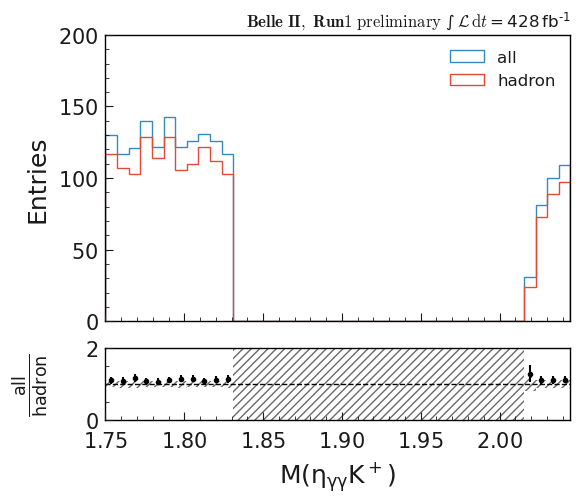

In [64]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_proc13_skimhad[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.75,2.045)

h1 = make_hist(x1, bins=40, range=x_range, weights=1)
h2 = make_hist(x2, bins=40, range=x_range, weights=1)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="all",
    h2_label="hadron",
    comparison="split_ratio",
)

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_all_hlt_compare_{tree_to_compare}_{name}.png", bbox_inches="tight")

In [73]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','skimhad']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [74]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [75]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,9042.000000,9042.000000,9042.000000,9042.000000,9042.000000,9042.000000
mean,1.671792,0.286056,0.517699,1.643049,0.005751,0.996461
std,0.141081,0.471382,0.438969,0.747132,1.000039,0.059388
min,1.500001,-0.939600,-0.884499,0.400289,-1.000000,0.000000
25%,1.577084,-0.070378,0.243290,1.058528,-1.000000,1.000000
50%,1.635976,0.405366,0.684751,1.556316,1.000000,1.000000
75%,1.724222,0.679105,0.876953,2.104673,1.000000,1.000000
max,2.099920,0.999566,0.971987,4.729052,1.000000,1.000000


In [76]:
df_proc13 = df_proc13.query('Dp_M> 1.75 & Dp_M<2.045')


In [77]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,1342.000000,1342.000000,1342.000000,1342.000000,1342.000000,1342.000000
mean,1.827441,0.340544,0.576997,1.687349,-0.007452,0.994784
std,0.092159,0.468897,0.437127,0.785609,1.000345,0.072061
min,1.750002,-0.890706,-0.855511,0.403669,-1.000000,0.000000
25%,1.772188,0.023452,0.365218,1.112977,-1.000000,1.000000
50%,1.794658,0.451971,0.775285,1.623245,-1.000000,1.000000
75%,1.820481,0.727441,0.906179,2.147304,1.000000,1.000000
max,2.044977,0.997673,0.967262,4.729052,1.000000,1.000000


In [78]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
skimhad            False
dtype: bool


In [79]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz_skimhad"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','skimhad']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [80]:
df_proc13_skimhad = pd.concat(dataframes, ignore_index=True)


In [81]:
df_proc13_skimhad.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,8468.000000,8468.000000,8468.000000,8468.000000,8468.000000,8468.0
mean,1.671565,0.286446,0.517741,1.643112,0.004724,1.0
std,0.141033,0.471285,0.439060,0.745500,1.000048,0.0
min,1.500001,-0.939600,-0.884499,0.400289,-1.000000,1.0
25%,1.577303,-0.069143,0.243620,1.060890,-1.000000,1.0
50%,1.635631,0.406096,0.684787,1.558417,1.000000,1.0
75%,1.723358,0.679663,0.876846,2.104754,1.000000,1.0
max,2.099920,0.999566,0.971987,4.729052,1.000000,1.0


In [82]:
df_proc13_skimhad = df_proc13_skimhad.query('Dp_M> 1.75 & Dp_M<2.045')


In [83]:
df_proc13_skimhad.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,skimhad
count,1248.000000,1248.000000,1248.000000,1248.000000,1248.00000,1248.0
mean,1.826862,0.341528,0.579673,1.688468,-0.00641,1.0
std,0.091896,0.467069,0.436065,0.786396,1.00038,0.0
min,1.750002,-0.890706,-0.855511,0.403669,-1.00000,1.0
25%,1.771748,0.027094,0.377100,1.119739,-1.00000,1.0
50%,1.794588,0.450492,0.781020,1.632430,-1.00000,1.0
75%,1.819847,0.727883,0.905798,2.147802,1.00000,1.0
max,2.044977,0.997673,0.967262,4.729052,1.00000,1.0


In [84]:
nan_columns = df_proc13_skimhad.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
skimhad            False
dtype: bool


In [85]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


In [87]:
tree_to_compare = "etapip_pipipi_K"
plt.rcParams['font.family'] = 'DejaVu Sans'


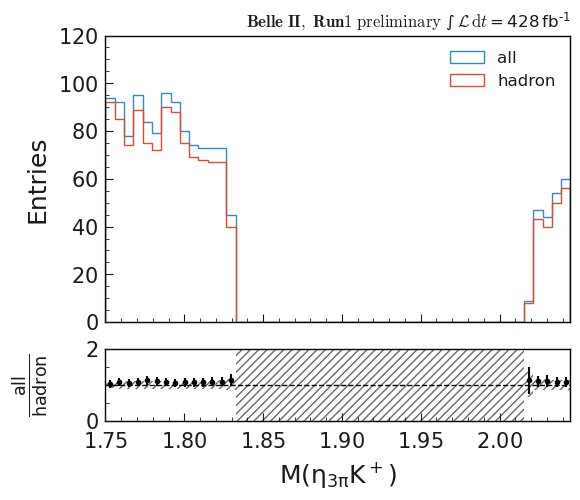

In [88]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_proc13_skimhad[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.75,2.045)

h1 = make_hist(x1, bins=50, range=x_range, weights=1)
h2 = make_hist(x2, bins=50, range=x_range, weights=1)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="all",
    h2_label="hadron",
    comparison="split_ratio",
)

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_all_hlt_compare_{tree_to_compare}_{name}.png", bbox_inches="tight")